<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%94%D0%97_Pro_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B8_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Возьмите из ноутбука по практическому занятия "Автокодировщики" сверточный вариационный энкодер или напишите свой и обучите его на датасете Emnist letters.

Датасет содержит изображения рукописных латинских букв.

Размер обучающей выборки 697932 изображений, тестовой - 116323.


Данный автокодировщик показывает весьма слабые результаты. При воспроизведении букв много "брака". Повысьте качество его работы. Обратите внимание на следущие гиперпараметры:
1. Размерность скрытого пространства
2. Количество сверточных слоев
3. Число эпох обучения

Главное добейтесь улучшения качества воспроизведения букв.

Визуализируйте результат улучшения качества воспроизведения букв.

Желаемое качество воспроизведения символов (пример ниже).

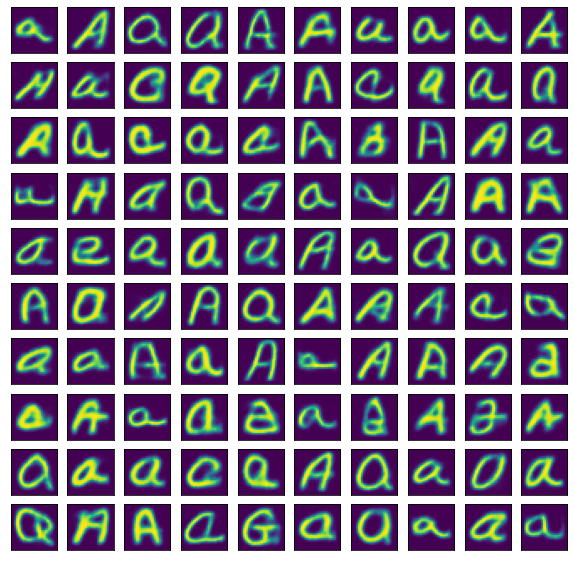

In [1]:
!pip install emnist

In [2]:
# Подключим Numpy
import numpy as np

# Подключим библиотеку отображения графиков
import matplotlib.pyplot as plt

# Импортируем Keras
from tensorflow import keras

import tensorflow as tf

# Подключим все необходимые слои Keras
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Lambda, LeakyReLU
from tensorflow.keras.layers import BatchNormalization, Dropout, concatenate, Conv2D, Conv2DTranspose

# Подключим модуль вычислений на Keras
import keras.backend as K

# Подключим датасет рукописных букв
from emnist import extract_training_samples, extract_test_samples

import emnist
emnist.SOURCE_URLS[1] = 'https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip'

# Подключим модуль работы с операционной системой
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # От tensorflow будет получать только ошибки

In [3]:
# Скачаем обучающую выборку
xs_train, y_train = extract_training_samples('letters')

# Скачаем тестовую выборку
xs_test, y_test = extract_test_samples('letters')

# Добавим 1 размерность numpy-массиву обучающей выборки + приведем к диапазону 0...1
x_train = np.reshape(xs_train, (len(xs_train), 28, 28, 1))/255.

# Добавим 1 размерность numpy-массиву тестовой выборки + приведем к диапазону 0...1
x_test = np.reshape(xs_test, (len(xs_test), 28, 28, 1))/255.

In [4]:
# Определим функцию отображения 100 картинок

def showResult(re): # Получим 100 картинок

    total = 10                               # Считаем полное количесво выводимых мультяшек +1
    plt.figure(figsize=(total, total))       # Создаем заготовку для финальной картинки 10x10
    num = 1                                  # Счетчик выводимых мультяшек
    for i in range(100):                     # Цикл по картинкам
        ax = plt.subplot(total, total, num)  # Добавим место для графика
        img = re[num-1:num,:,:,:]            # Сформируем очередную картинку
        num += 1                             # Инкремент номера графика
        plt.imshow(img.squeeze())            # Рисуем пмультяшек
        ax.get_xaxis().set_visible(False)    # Спрячем ось X
        ax.get_yaxis().set_visible(False)    # Спрячем ось Y

In [5]:
print (x_train.shape) # Выведем размерность обучающей выборки изображений
print (x_test.shape)  # Выведем размерность тестовой выборки изображений
print (y_train.shape) # Выведем размерность обучающей выборки меток
print (y_test.shape)  # Выведем размерность тестовой выборки меток

(124800, 28, 28, 1)
(20800, 28, 28, 1)
(124800,)
(20800,)


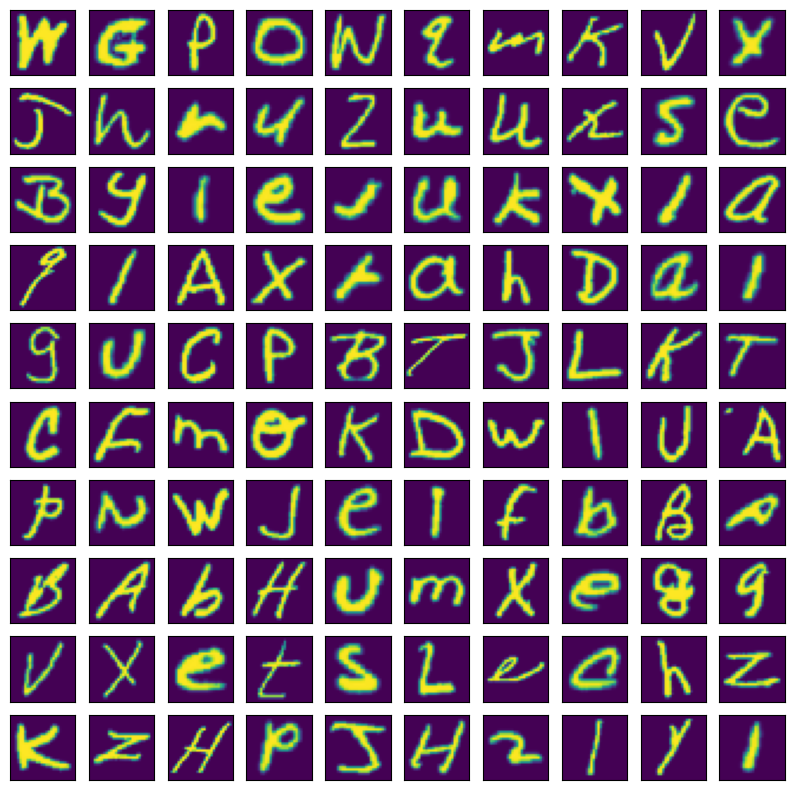

In [6]:
# Взглянем на первые 100 изображений обучающей выборки

showResult(x_train[:100,:,:,:])

In [7]:
# Взглянем на первые 100 меток обучающей выборки

y_train[:100]

array([23,  7, 16, 15, 23, 17, 13, 11, 22, 24, 10, 14, 18, 21, 26, 21, 21,
       24, 19,  5,  2, 25,  9,  5, 10, 21, 11, 24, 12,  1, 17,  9,  1, 24,
       18,  1,  8,  4,  1,  9,  7, 21,  3, 16,  2, 20, 10, 12, 11, 20,  3,
        6, 13, 15, 11,  4, 23, 12, 21,  1, 16, 14, 23, 10,  5, 12,  6,  2,
        2,  1,  2,  1,  2,  8, 21, 13, 24,  5,  7,  7, 22, 24,  5, 20, 19,
       12,  5,  3,  8, 26, 11, 26,  8, 16, 10,  8, 26, 12, 25,  9],
      dtype=uint8)

In [8]:
# Ваше решение
hidden_dim = 2  # Зададим размерность скрытого пространства AE

batch_size = 60 # Задамим размер батча для обучения AE(должно быть кратно 60 000)

In [9]:
# Определим функцию отображения результатов работы декодера

def showResult(decoder): # Получим обученный декодер

    n = 5
    total = 2*n+1                                                     # Считаем полное количесво выводимых цифр +1
    plt.figure(figsize=(total, total))                                # Создаем заготовку для финальной картинки
    num = 1                                                           # Счетчик выводимых цифр
    for i in range(-n, n+1):                                          # Цикл по горизонтали пространства Z
     for j in range(-n, n+1):                                         # Цикл по вертикали пространства Z
        ax = plt.subplot(total, total, num)                           # Добавим место для графика
        num += 1                                                      # Инкремент номера графика
        img = decoder.predict(np.expand_dims([3*i/n, 3*j/n], axis=0)) # Выполним предикт изображения цифры по точкам из Z области
        plt.imshow(img.squeeze(), cmap='gray')                        # Рисуем предсказанную цифру
        ax.get_xaxis().set_visible(False)                             # Спрячем ось X
        ax.get_yaxis().set_visible(False)                             # Спрячем ось Y

In [10]:
# Создадим функцию сборки блока построения сверточного энкодера

def encoderBlock(xin,        # Входной тензор
                 neu=8,      # Число нейроной сверточного слоя
                 kernel=3,   # Размер ядра сверточного слоя
                 strides=1): # Число шагом сверточного слоя

    # Составим блок сети
    x = Conv2D(neu, kernel_size=kernel, strides= strides, padding='same')(xin) # Добавим 2D свертку
    x = BatchNormalization()(x)                                                # Добавим нормализацию по батчу
    x = LeakyReLU()(x)                                                         # Добавим функцию активации

    # Вернем выходной тензор
    return x


# Создадим функцию сборки блока построения сверточного декодера

def decoderBlock(xin,        # Входной тензор
                 neu=8,      # Число нейроной сверточного слоя
                 kernel=3,   # Размер ядра сверточного слоя
                 strides=1): # Число шагом сверточного слоя

    # Составим блок сети
    x = Conv2DTranspose(neu, kernel_size=kernel, strides= strides, padding='same')(xin)  # Добавим обратную 2D свертку
    x = BatchNormalization()(x)                                                          # Добавим нормализацию по батчу
    x = LeakyReLU()(x)                                                                   # Добавим функцию активации

    # Вернем выходной тензор
    return x

In [11]:
# Создадим сверточный энкодер

input_img = Input(shape=(28, 28, 1))                     # Добавим входной слой
x = encoderBlock(input_img, neu=32, kernel=3, strides=1) # Добавим 1-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 2-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=2)         # Добавим 3-й блок свертка+нормализация+активашка
x = encoderBlock(x, neu=64, kernel=3, strides=1)         # Добавим 4-й блок свертка+нормализация+активашка
flatten =Flatten()(x)                                    # Добавим Flatten
x = Dense(2, activation='linear')(flatten)               # Добавим выходной dense слой

In [12]:
z_mean = Dense(hidden_dim)(x)        # Добавим dense для получения мат.ожидания
z_log_var = Dense(hidden_dim)(x)     # Добавим dense для получения логарифма дисперсии

In [13]:
import keras.ops as ops
import keras.random as kr

def noiser(args):
    z_mean, z_log_var = args

    batch = ops.shape(z_mean)[0]  # размер батча берём из KerasTensor
    N = kr.normal(shape=(batch, hidden_dim), mean=0.0, stddev=1.0)

    return z_mean + ops.exp(0.5 * z_log_var) * N

h = keras.layers.Lambda(noiser, output_shape=(hidden_dim,))([z_mean, z_log_var])
      # Создадим свой слой - лямбда. На входе мат.ожидание и логарифм дисперсии
                                                                          # На выходе - тензор случайных чисел

In [14]:
 # Соберем энкодер

encoderVAEС = keras.Model(input_img, [z_mean, z_log_var, h], name='encoder')

In [15]:
# Создадим сверточный декодер

input_enc = Input(shape=(2,))                            # Добавим входной слой
x = Dense(3136, name='dense_1')(input_enc)               # Добавим dense в 7х7х64 = 3136 нейронами
x = Reshape((7, 7, 64))(x)                               # Решейпим 1D тензор в 3D тензор
x= decoderBlock(x, neu=64, kernel=3, strides=1)          # Добавим 1-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=64, kernel=3, strides=2)          # Добавим 2-й блок обратная свертка+нормализация+активашка
x= decoderBlock(x, neu=32, kernel=3, strides=2)          # Добавим 3-й блок обратная свертка+нормализация+активашка

decoded = Conv2DTranspose(1, 3, 1,padding='same', activation='sigmoid', name='conv_transpose_4')(x)# Добавим выходной слой

In [16]:
# Соберем декодер

decoderVAEС = keras.Model(input_enc, decoded, name='decoder')

In [17]:
# Запишем выражение для декодера, заметим, что за вход декодера подается только 1 их выходов энкодера

outputs = decoderVAEС(encoderVAEС(input_img)[2])

In [18]:
# Соберем наши сетки

vaec = keras.Model(input_img, decoderVAEС(encoderVAEС(input_img)[2])) # Соберем VAE

In [19]:
import keras
import keras.ops as ops

class VAELossLayer(keras.layers.Layer):
    def call(self, inputs):
        input_img, outputs, z_mean, z_log_var = inputs

        # MSE вручную (т.к. keras.losses.mse нет)
        reconstruction_loss = ops.mean(ops.square(input_img - outputs), axis=(1, 2, 3))
        reconstruction_loss *= 28 * 28

        kl_loss = 1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var)
        kl_loss = -0.5 * ops.sum(kl_loss, axis=-1)

        vae_loss = ops.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)

        return outputs  # просто пробрасываем реконструкцию

# Использование:
outputs = VAELossLayer()([input_img, outputs, z_mean, z_log_var])
vaec = keras.Model(input_img, outputs)                                   # Отдадим наш лосс VAE


In [20]:
# Выведем состав энкодера
encoderVAEС.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     18,496 │ leaky_re_lu[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │      6,274 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │          6 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │          6 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,854 (390.05 KB)

 Trainable params: 99,406 (388.30 KB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
#  Выведем состав энкодера
decoderVAEС.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_4                │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,657 (401.00 KB)

 Trainable params: 102,337 (399.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [22]:
# Компилируем VAE

vaec.compile(optimizer='adam') # оптимайзер ADAM

In [23]:
# Запускаем обучениe

vaec.fit(x_train,      # Обучающая выборка
        x_train,       # "Labels" обучающей выборки
        epochs=15,     # 15 эпох
        batch_size=60, # размер батча
        shuffle=True)  # обучающую выборку перемешиваем

Epoch 1/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step - loss: 64.4093
Epoch 2/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 55.9056
Epoch 3/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 54.7829
Epoch 4/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 54.1477
Epoch 5/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 53.7441
Epoch 6/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 53.3197
Epoch 7/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 53.0265
Epoch 8/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 52.8434
Epoch 9/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 52.6076
Epoch 10/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 52.4065
Epoch 11/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 52.2780
Epoch 12/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 52.2406
Epoch 13/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 51.9907
Epoch 14/15
2080/2080 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 51.8946
E

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


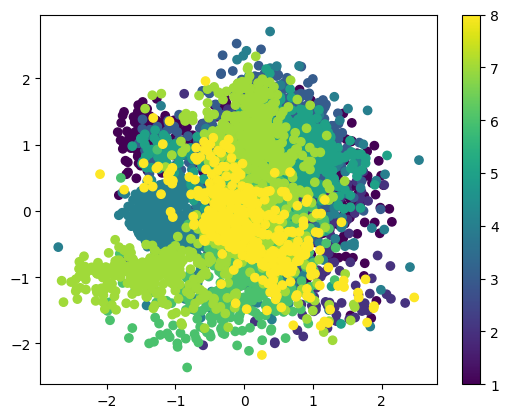

In [24]:
h = encoderVAEС.predict(x_test[:6000], batch_size=batch_size)    # Предиктим энкодером первые 6000 цизображений букв
plt.scatter(h[2][:, 0], h[2][:, 1] , c=y_test[:6000], cmap='viridis') # Выводим  скаттер координат точек скрытого пространства
plt.colorbar()                                                  # Выводим цветовую шкалу - каждому классу свой цвет
plt.show()                                                      # Отрисуем картинку

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 951ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━

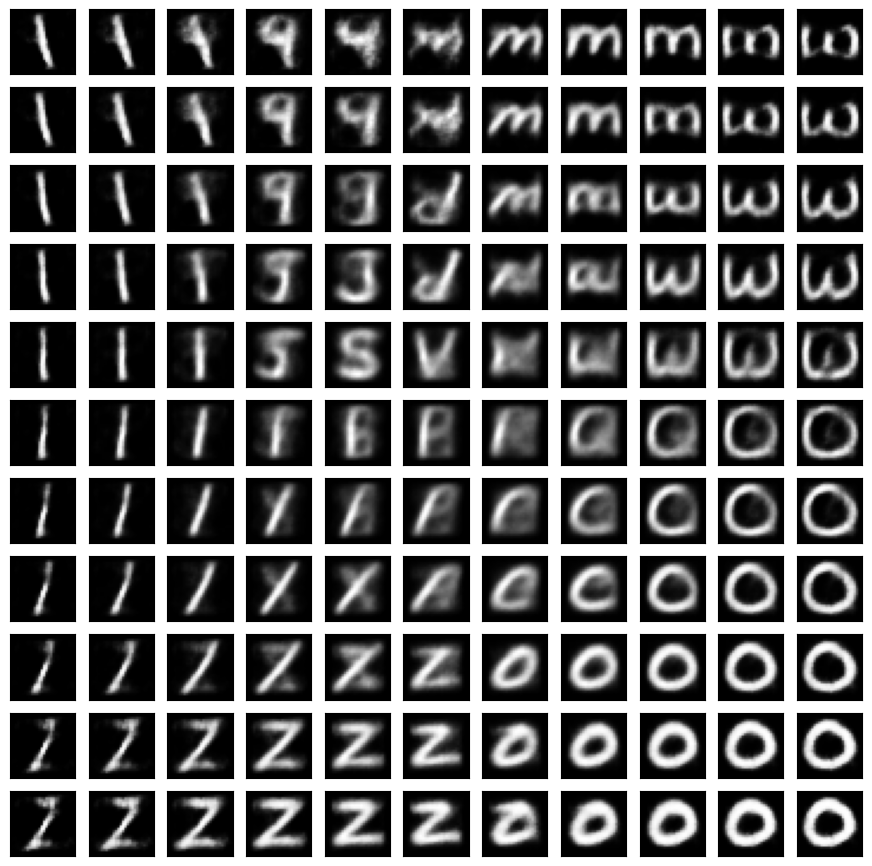

In [25]:
# Выведем 100 цифр, сгенерированных декодером

showResult(decoderVAEС)